In [1]:
#install.packages(c("tm", "SnowballC", "topicmodels", "wordcloud"))
library("tm")
library("SnowballC")
library("topicmodels")
library("wordcloud")

Loading required package: NLP

Loading required package: RColorBrewer



In [2]:
d <- read.csv("News.csv", header = TRUE)
head(d,1)

,doc_id,text,date,heading
,<int>,<chr>,<chr>,<chr>
1,1,"KARACHI: The Sindh government has decided to bring down public transport fares by 7 per cent due to massive reduction in petroleum product prices by the federal government, Geo News reported.Sources said reduction in fares will be applicable on public transport, rickshaw, taxi and other means of traveling.Meanwhile, Karachi Transport Ittehad (KTI) has refused to abide by the government decision.KTI President Irshad Bukhari said the commuters are charged the lowest fares in Karachi as compare to other parts of the country, adding that 80pc vehicles run on Compressed Natural Gas (CNG). Bukhari said Karachi transporters will cut fares when decrease in CNG prices will be made.",1/1/2015,sindh govt decides to cut public transport fares by 7pc kti rej


In [9]:
dcorp <- Corpus(DataframeSource(d))

In [11]:
# 1. Remove punctuation
cleancorp <- tm_map(dcorp, removePunctuation)

# 2. Remove numbers
cleancorp <- tm_map(cleancorp, removeNumbers)

# 3. Strip extra whitespace
cleancorp <- tm_map(cleancorp, stripWhitespace)

# 4. Remove English stopwords
cleancorp <- tm_map(cleancorp, removeWords, stopwords('english'))

# 5. Stem the documents (requires the 'SnowballC' package)
cleancorp <- tm_map(cleancorp, stemDocument)

In [27]:
DTM <- DocumentTermMatrix(cleancorp, control = list(bounds = list(global =c(3,Inf))))
dim(DTM)
nTerms(DTM)
nDocs(DTM)
DTM$dimnames$Terms[1:50]

[1] 1167 5131

[1] 5131

[1] 1167

[1] "abid"      "applic"    "bring"     "cent"      "charg"     "cng"      
 [7] "commut"    "compar"    "compress"  "countri"   "cut"       "decid"    
[13] "decreas"   "due"       "fare"      "feder"     "gas"       "geo"      
[19] "govern"    "irshad"    "karachi"   "lowest"    "made"      "massiv"   
[25] "mean"      "natur"     "new"       "part"      "per"       "petroleum"
[31] "presid"    "price"     "product"   "public"    "reduct"    "refus"    
[37] "run"       "said"      "sindh"     "taxi"      "the"       "transport"
[43] "vehicl"    "will"      "activ"     "administr" "afp"       "afternoon"
[49] "agribusi"  "ahead"

In [28]:
row.indx <- slam::row_sums(DTM)>0
DTM <- DTM[row.indx, ]
textdata <- d[row.indx,]
dim(DTM)

[1] 1167 5131

In [29]:
set.seed(1000)
tm <- LDA(DTM,20,method="Gibbs",control=list(iter = 1000, verbose = 50))

tm.res <- posterior(tm)

K = 20; V = 5131; M = 1167
Sampling 1000 iterations!
Iteration 50 ...
Iteration 100 ...
Iteration 150 ...
Iteration 200 ...
Iteration 250 ...
Iteration 300 ...
Iteration 350 ...
Iteration 400 ...
Iteration 450 ...
Iteration 500 ...
Iteration 550 ...
Iteration 600 ...
Iteration 650 ...
Iteration 700 ...
Iteration 750 ...
Iteration 800 ...
Iteration 850 ...
Iteration 900 ...
Iteration 950 ...
Iteration 1000 ...
Gibbs sampling completed!


In [30]:
beta <- tm.res$terms
dim(beta)
beta[,1:5]
rowSums(beta)

[1]   20 5131

,abid,applic,bring,cent,charg
1,1.116557e-05,7.927558e-04,3.461328e-04,1.116557e-05,9.044115e-04
2,1.241450e-05,1.241450e-05,1.241450e-05,1.241450e-05,1.241450e-05
3,1.074218e-05,1.074218e-05,7.626946e-04,4.404293e-04,1.074218e-05
4,1.206840e-05,1.327524e-04,1.206840e-05,1.339593e-03,1.206840e-05
5,1.302066e-05,3.658807e-03,1.302066e-05,1.302066e-05,5.742113e-03
6,1.110112e-05,1.110112e-05,1.110112e-05,1.110112e-05,1.121213e-03
7,2.187705e-04,4.271234e-04,2.198123e-03,1.041764e-05,1.041764e-05
8,1.155789e-05,1.155789e-05,1.155789e-05,1.155789e-05,1.155789e-05
9,8.691798e-06,8.691798e-06,8.691798e-06,8.691798e-06,8.691798e-06
10,1.227883e-05,1.227883e-05,3.327562e-03,1.227883e-05,1.227883e-05


1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 
 1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1  1

In [31]:
theta <- tm.res$topics
dim(theta)
theta[1:5,]
rowSums(theta)[1:10]

[1] 1167   20

,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
1,0.03097345,0.03097345,0.03097345,0.03097345,0.28761062,0.02212389,0.03097345,0.03982301,0.066371681,0.030973451,0.03097345,0.02212389,0.03982301,0.02212389,0.03982301,0.02212389,0.092920354,0.03982301,0.05752212,0.03097345
2,0.00751073,0.01609442,0.06115880,0.03540773,0.01180258,0.03326180,0.02682403,0.01824034,0.009656652,0.009656652,0.04184549,0.13412017,0.09763948,0.07403433,0.02682403,0.32296137,0.013948498,0.03111588,0.00751073,0.02038627
3,0.03289474,0.03289474,0.03289474,0.04605263,0.04605263,0.03289474,0.04605263,0.03289474,0.046052632,0.032894737,0.03289474,0.04605263,0.04605263,0.03289474,0.03289474,0.25657895,0.032894737,0.03289474,0.05921053,0.04605263
4,0.01900585,0.03362573,0.01900585,0.01315789,0.01315789,0.01023392,0.01608187,0.06286550,0.027777778,0.016081871,0.02192982,0.11257310,0.16520468,0.03362573,0.02485380,0.27339181,0.007309942,0.03654971,0.07748538,0.01608187
5,0.01371571,0.00872818,0.03366584,0.01870324,0.01620948,0.01870324,0.01870324,0.03865337,0.135910224,0.013715711,0.02618454,0.22319202,0.19825436,0.03117207,0.04114713,0.04114713,0.018703242,0.04114713,0.05361596,0.00872818


1  2  3  4  5  6  7  8  9 10 
 1  1  1  1  1  1  1  1  1  1

In [32]:
terms(tm, 10)

Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
servic,said,china,job,price,bank,tax,european,oil,india,dollar,crude,market,percent,pakistan,percent,pakistan,million,will,product
new,offici,world,percent,gas,compani,said,said,opec,import,percent,oil,price,bank,financ,stock,project,year,said,new
busi,the,trade,said,per,state,govern,britain,output,pakistan,rate,barrel,global,growth,sector,point,said,billion,year,said
use,talk,invest,month,power,said,billion,like,iran,offer,gold,price,sinc,economi,govern,index,minist,export,next,market
make,govern,chines,report,billion,financi,feder,take,saudi,industri,week,cent,low,expect,said,yen,countri,last,also,year
said,foreign,economi,trump,the,includ,rupe,leav,product,custom,fed,week,fall,econom,minist,share,power,countri,around,korea
mobil,issu,will,new,petroleum,fund,minist,one,produc,cotton,high,suppli,drop,rate,econom,close,develop,month,three,cosmet
oper,exchang,manufactur,market,sourc,nation,revenu,vote,cut,sale,hike,said,level,year,imf,fell,energi,compar,plan,compani
can,two,report,last,said,law,financ,month,arabia,car,interest,demand,monday,also,fund,gain,also,increas,two,brand
includ,say,asia,also,increas,report,the,europ,meet,local,reserv,brent,analyst,polici,support,trade,karachi,percent,due,major


[1] "strong>WASHINGTON: Republican Donald Trump scored a series of shocking wins in battleground U.S. states including Florida and Ohio on Tuesday, opening a path to the White House for the political outsider and rattling world markets that had counted on a win by Democrat Hillary Clinton.</strongWith investors worried a Trump victory could cause economic and global uncertainty, the U.S. dollar sank and stock markets plummeted in wild Asian trading. Opinion polls before Election Day had given Clinton a slim lead.Mexico's peso plunged to its lowest-ever levels as Trump's chances of winning the presidency increased. Concerns of a Trump victory have weighed heavily on the peso for months because of his threats to rip up a free trade agreement with Mexico and tax money sent home by migrants to pay to build a wall on the southern U.S. border.Trump surged to wins in Florida, Ohio, Iowa and North Carolina, and Fox News projected a win for him in Wisconsin. With voting completed in 49 of the 50 U.S. states, he also narrowly led in Michigan and New Hampshire, edging him closer to 270 Electoral College votes needed to win the state-by-state fight for the White House.Shortly after Fox called Wisconsin for Trump, supporters at his election evening rally in New York began to chant \"Lock her up\" - a common refrain on the campaign trail for the former U.S. secretary of state repeatedly dubbed \"Crooked Hillary\" by Trump.Clinton still had ways to reach 270 electoral votes, but she would have to sweep the remaining battleground states including Pennsylvania, Michigan and Nevada, and pull off an upset win in Arizona.Trump captured conservative states in the South and Midwest, while Clinton swept several states on the East Coast and Illinois in the Midwest.After running close throughout the night in Virginia, Clinton pulled out the swing state that is home to her running mate, Senator Tim Kaine. But TrumpAt 8:55 p.m. EST, Clinton acknowledged a battle that was unexpectedly tight given her edge in opinion polls going into Election Day.She tweeted: \"This team has so much to be proud of. Whatever happens tonight, thank you for everything.\"As of 11:40 p.m. EST, Trump had 244 electoral votes to Clinton?s 209, with U.S. television networks projecting the winner in 41 of the 50 states and the District of Columbia.A wealthy real-estate developer and former reality TV host, Trump rode a wave of anger toward Washington insiders to challenge Clinton, whose gold-plated establishment resume includes stints as a first lady, U.S. senator and secretary of state.strong>UNPOPULAR CANDIDATES</strongBoth candidates had historically low popularity ratings, although Trump's were worse than Clinton's, in an election that many voters characterized as a choice between two unpleasant alternatives.Before Tuesday's voting, Clinton led Trump, 44 percent to 39 percent in the last Reuters/Ipsos national tracking poll. A Reuters/Ipsos States of the Nation poll gave her a 90 percent chance of defeating Trump and becoming the first woman elected U.S. president.Also at stake on Tuesday was control of Congress. Television networks projected Republicans would retain control of the House of Representatives, where all 435 seats were up for grabs.In the Senate, where Republicans were defending a slim four-seat majority, Democrats scored their first breakthrough in Illinois when Republican Senator Mark Kirk lost re-election. But Republicans Rob Portman in Ohio and Marco Rubio in Florida won high-profile Senate re-election fights.In a presidential campaign that focused more on the character of the candidates than on policy, Clinton, 69, and Trump, 70, accused each other of being fundamentally unfit to lead the country.Trump entered the race 17 months ago and survived a series of seemingly crippling blows, many of them self-inflicted, including the emergence in October of a 2005 video in which he boasted about making unwanted sexual advances on women. He apologized but within days, 

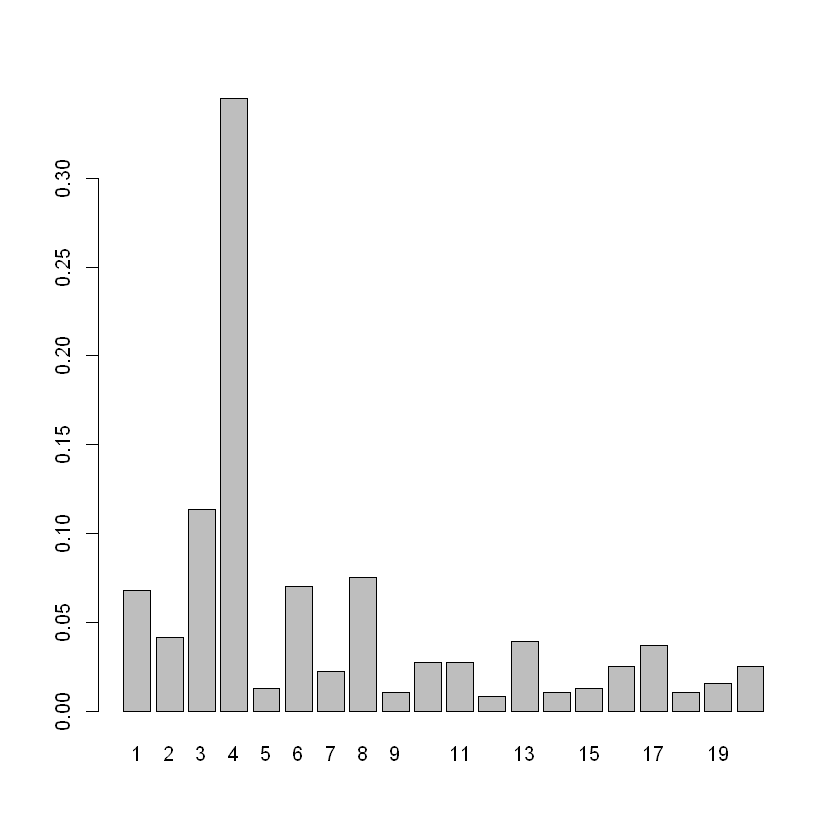

In [40]:
as.character(dcorp[1082]$content)
barplot(theta[1082,])

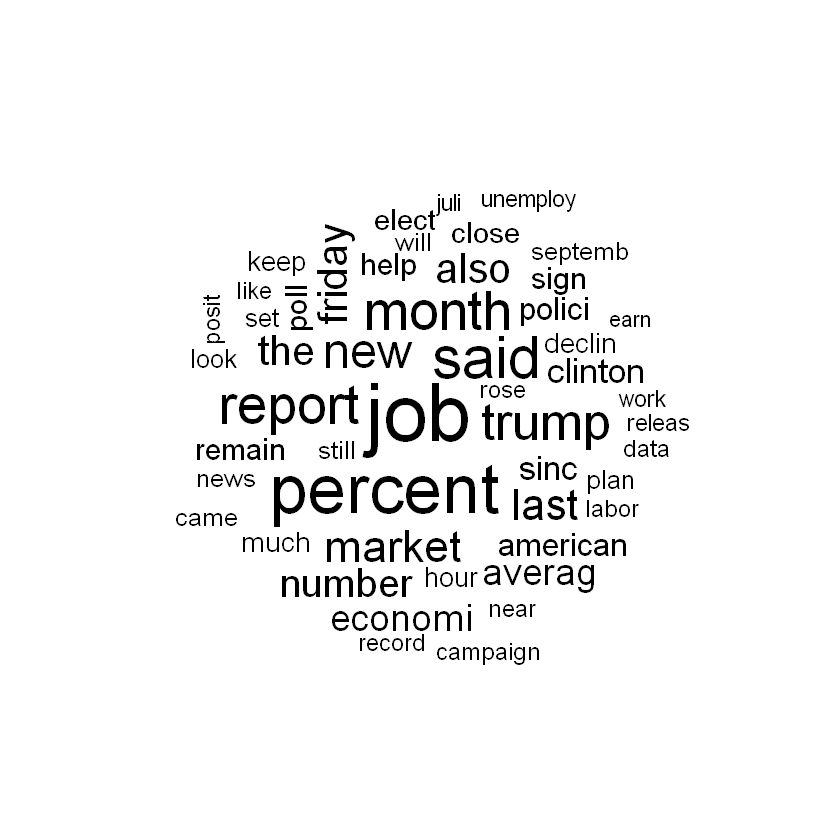

In [41]:
top.term.prob <- sort(beta[4,], decreasing = TRUE)[1:50]
wordcloud(names(top.term.prob), top.term.prob, random.order = FALSE)

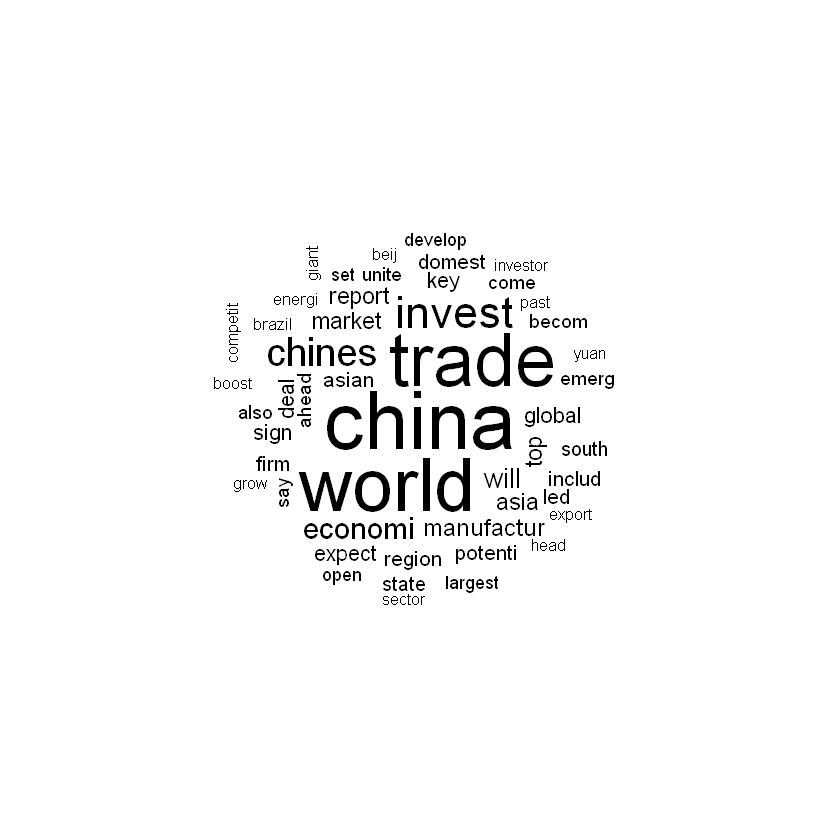

In [42]:
top.term.prob <- sort(beta[3,], decreasing = TRUE)[1:50]
wordcloud(names(top.term.prob), top.term.prob, random.order = FALSE)

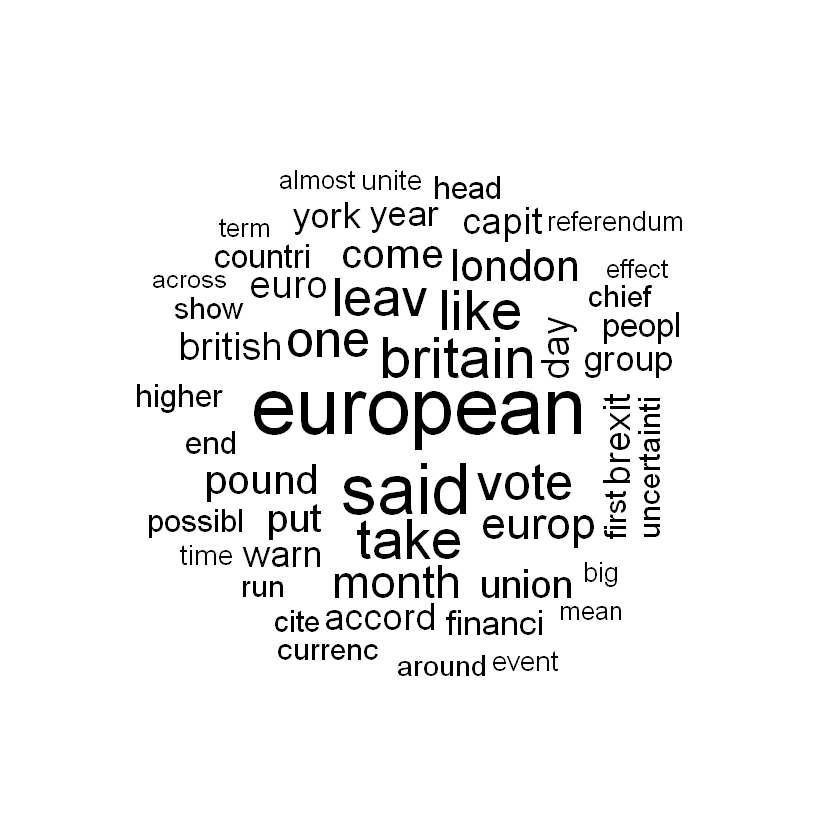

In [43]:
top.term.prob <- sort(beta[8,], decreasing = TRUE)[1:50]
wordcloud(names(top.term.prob), top.term.prob, random.order = FALSE)